In [4]:
import modules.hopfield_network as hp

In [5]:
import matplotlib.image as mimg
import numpy as np
import matplotlib.pyplot as plt
import cv2

[[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]]


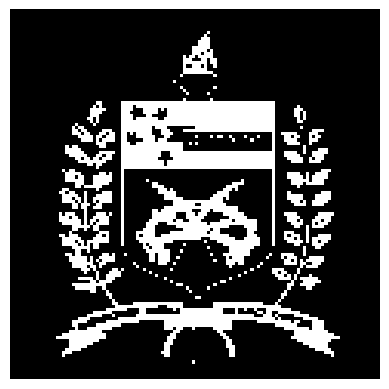

In [6]:
#transformando a imagem em um vetor
img_ufsc    = mimg.imread('dataset/ufsc.png')
img_ufsc_BW = (np.mean(img_ufsc,axis=2)>0.6).astype(float)

#transformando o vetor em um quadrado perfeito
h, w = img_ufsc_BW.shape
lado = max(h, w)
img_quad = np.ones((lado, lado))
y = (lado - h) // 2
x = (lado - w) // 2
img_quad[y:y+h, x:x+w] = img_ufsc_BW

#renormalizando a dimensionalidade do array
img_400 = cv2.resize(img_quad, (120, 120), interpolation=cv2.INTER_NEAREST)

img_400 = 2 * img_400 - 1

print(img_400)

#plotando a imagem finalc
plt.imshow(img_400*-1, cmap='gray', vmin=-1, vmax=1)
plt.axis('off')
plt.show()

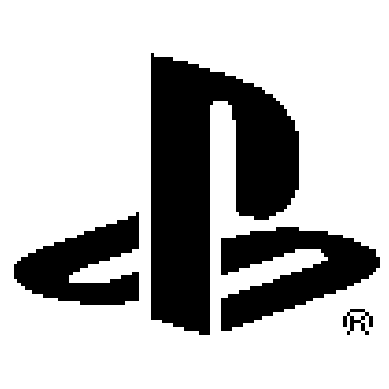

In [7]:
#transformando a imagem em um vetor
img_ufsc    = mimg.imread('dataset/playstation.png')
img_ufsc_BW = (np.mean(img_ufsc,axis=2)>0.3).astype(float)

#transformando o vetor em um quadrado perfeito
h, w = img_ufsc_BW.shape
lado = max(h, w)
img_quad = np.zeros((lado, lado))
y = (lado - h) // 2
x = (lado - w) // 2
img_quad[y:y+h, x:x+w] = img_ufsc_BW

#renormalizando a dimensionalidade do array
img_400 = cv2.resize(img_quad, (100, 100), interpolation=cv2.INTER_NEAREST)

#invertendo as cores
img_inv = 1 - img_400

#plotando a imagem final
plt.imshow(img_inv, cmap='gray')
plt.axis('off')
plt.show()

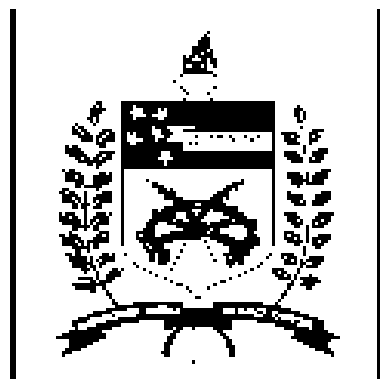

In [8]:
img_ufsc = mimg.imread('dataset/ufsc.png')
img_ufsc_BW = (np.mean(img_ufsc[:,:,:4], axis=2) > 0.6).astype(float)

h, w = img_ufsc_BW.shape
lado = max(h, w)

img_quad = np.zeros((lado, lado))   # fundo preto

y = (lado-h)//2
x = (lado-w)//2

img_quad[y:y+h, x:x+w] = img_ufsc_BW

img_120 = cv2.resize(img_quad, (120,120), interpolation=cv2.INTER_NEAREST)

img_120 = 2*img_120 - 1

plt.imshow(img_120, cmap='gray', vmin=-1, vmax=1)
plt.axis('off')
plt.show()

In [9]:
def preprocessar_para_hopfield(img_path, size, threshold, swap_colors):
    """
    Loads an image and preprocesses it for use in Hopfield networks.

    The pipeline performs:

    1. Image loading from the given file path.
    2. Binary conversion using a threshold.
    3. Logical inversion to represent:
        - dark object as 1
        - light background as 0
    4. Detection of the active image region.
    5. Automatic cropping of useful content.
    6. Padding into a square canvas using the dominant border color.
    7. Resizing to a fixed resolution (size x size).
    8. Conversion to bipolar representation:
        -1 = background
        +1 = object
    9. Flattening into a vector for Hopfield input.
    10. Optional bipolar color inversion.

    Parameters
    ----------
    img_path : str
        Path to the image file.

    size : int
        Desired final square image size.
        Example: size=120 produces a 120x120 image.

    threshold : float
        Threshold used for binarization.
        Values above threshold become white.
        Values below threshold become black.

        Typical range:
        0.0 to 1.0

    swap_colors : bool
        If True, inverts the final bipolar encoding:
            +1 <-> -1

        Useful when the main object polarity is reversed.

    Returns
    -------
    img_final : numpy.ndarray
        2D matrix with shape (size, size) containing only {-1, +1} values.

    vector : numpy.ndarray
        Flattened 1D version of the final image.
        Shape = (size*size,)

    Notes
    -----
    This function is suitable for:

    - Hopfield networks
    - Associative memory
    - Binary pattern recognition
    - Logos, symbols, and characters

    Requirements
    ------------
    numpy
    matplotlib.image
    cv2
    """

    # -------------------------------------------------
    # 1. Converter para grayscale/binário
    # -------------------------------------------------
    img = mimg.imread(img_path)
    if img.ndim == 3:
        img_bw = (np.mean(img[:, :, :4], axis=2) > threshold).astype(float)
    else:
        img_bw = (img > threshold).astype(float)

    # Inverte: objeto preto vira 1, fundo branco vira 0
    img_bw = 1 - img_bw

    # -------------------------------------------------
    # 2. Encontrar conteúdo ativo
    # -------------------------------------------------
    rows, cols = np.where(img_bw == 1)

    top    = rows.min()
    bottom = rows.max()
    left   = cols.min()
    right  = cols.max()

    # Corte solicitado
    img_crop = img_bw[top:bottom+2, left:right+2]

    # -------------------------------------------------
    # 3. Descobrir cor dominante da borda do recorte
    # -------------------------------------------------
    borda = np.concatenate([
        img_crop[0, :],
        img_crop[-1, :],
        img_crop[:, 0],
        img_crop[:, -1]
    ])

    cor_borda = round(np.mean(borda))   # 0 ou 1

    # -------------------------------------------------
    # 4. Transformar em quadrado
    # -------------------------------------------------
    h, w = img_crop.shape
    lado = max(h, w)

    img_quad = np.ones((lado, lado)) * cor_borda

    y = (lado - h) // 2
    x = (lado - w) // 2

    img_quad[y:y+h, x:x+w] = img_crop

    # -------------------------------------------------
    # 5. Resize
    # -------------------------------------------------
    img_final = cv2.resize(
        img_quad,
        (size, size),
        interpolation=cv2.INTER_NEAREST
    )

    # -------------------------------------------------
    # 6. Converter para bipolar {-1,+1}
    # -------------------------------------------------
    img_final = 2 * img_final - 1

    # -------------------------------------------------
    # 7. Vetorizar
    # -------------------------------------------------
    vetor = img_final.flatten()

    if swap_colors == True:
        vetor = -vetor
        img_final = -img_final

    return img_final, vetor

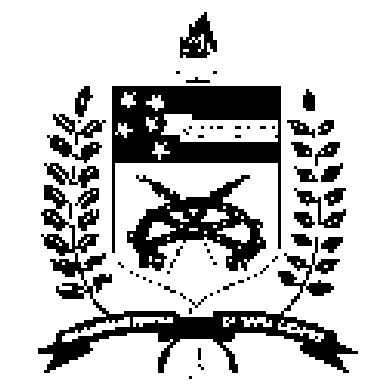

In [10]:
img_ufsc, vetor_ufsc = preprocessar_para_hopfield('dataset/ufsc.png', size=120, threshold=0.6, swap_colors=True)
plt.imshow(img_ufsc, cmap='gray', vmin=-1, vmax=1)
plt.axis('off')
plt.show()

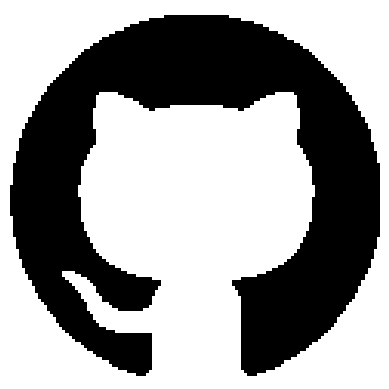

In [11]:
img_github, vetor_github = preprocessar_para_hopfield('dataset/github.png', size=120, threshold=0.60, swap_colors=True)
plt.imshow(img_github, cmap='gray', vmin=-1, vmax=1)
plt.axis('off')
plt.show()

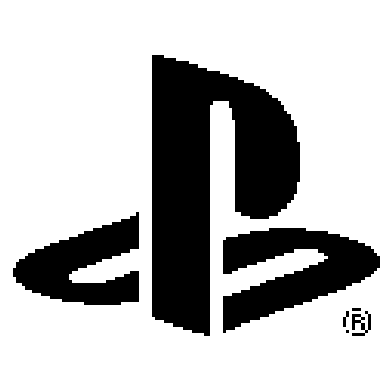

In [12]:
img_playstation, vetor_playstation = preprocessar_para_hopfield('dataset/playstation.png', size=120, threshold=0.3, swap_colors=False)
plt.imshow(img_playstation, cmap='gray', vmin=-1, vmax=1)
plt.axis('off')
plt.show()

In [13]:
#colocar possivel inversão de cores dentro da função preprocessar_para_hopfield, para evitar ter que inverter a imagem manualmente depois de processada.    

## Visualizing weight matrix:

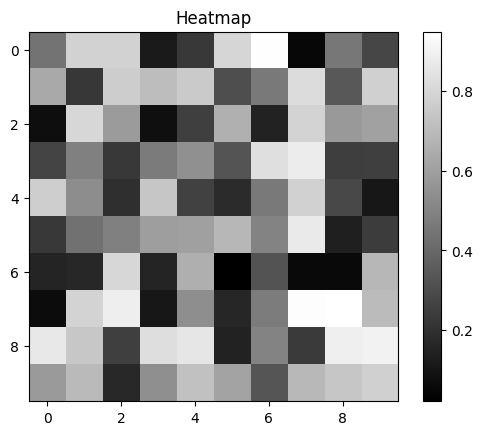

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Example matrix
matrix = np.random.rand(10, 10)

plt.imshow(matrix, cmap='gray')  # colormap can be changed
plt.colorbar()  # shows the scale
plt.title("Heatmap")
plt.show()